# 02 Criteo ads interference designs

This notebook uses Criteo uplift data as the ads incrementality anchor. The observed randomized lift calibrates a semi-synthetic ads marketplace layer with budget and exposure spillovers. The outputs are the design-risk ranking, Pareto frontier, uncertainty shortlist, and bias-variance frontier for an ads-motivated interference channel.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from data_cases import criteo_calibration, load_criteo_sample, run_criteo_ads_design_case
from designs import design_recommendations, pareto_frontier, uncertainty_shortlist
from figures import plot_bias_variance_frontier, plot_design_risk
from progress import ProgressLogger
from tables import write_table

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("02-domain")

In [2]:
progress.log("Loading a Criteo uplift sample directly from gzip.")
criteo_path = paths.data_dir / "criteo" / "criteo-research-uplift-v2.1.csv.gz"
sample = load_criteo_sample(criteo_path, nrows=300_000)
calibration = criteo_calibration(sample)
write_table(pd.DataFrame([calibration]), paths.table_dir / "02_criteo_calibration.csv")
calibration

[04:15:44] 02-domain: Loading a Criteo uplift sample directly from gzip.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/02_criteo_calibration.csv


{'n_rows': 300000.0,
 'treatment_rate': 0.5,
 'visit_rate': 0.023776666666666668,
 'conversion_rate': 0.004073333333333333,
 'exposure_rate': 0.01311,
 'visit_lift': 0.00298,
 'conversion_lift': 0.00148}

In [3]:
progress.log("Running ads design comparison calibrated to the Criteo randomized lift.")
summary = run_criteo_ads_design_case(sample, n_reps=120)
ranked = design_recommendations(summary)
write_table(ranked, paths.table_dir / "02_criteo_ads_design_scores.csv")
frontier = pareto_frontier(ranked)
shortlist = uncertainty_shortlist(ranked)
write_table(frontier, paths.table_dir / "02_criteo_ads_pareto_frontier.csv")
write_table(shortlist, paths.table_dir / "02_criteo_ads_uncertainty_shortlist.csv")
ranked[["design", "design_risk", "exposure_distance", "assignment_unit_variance", "planning_mde", "contamination_risk", "operational_cost", "estimand_mismatch"]]

[04:15:55] 02-domain: Running ads design comparison calibrated to the Criteo randomized lift.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/02_criteo_ads_design_scores.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/02_criteo_ads_pareto_frontier.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/02_criteo_ads_uncertainty_shortlist.csv


,design,design_risk,exposure_distance,assignment_unit_variance,planning_mde,contamination_risk,operational_cost,estimand_mismatch
0,user_randomization,1.294505,0.515833,0.005870,0.005539,0.247392,0.10,0.515833
1,switchback,1.920549,0.793397,0.000073,0.008875,0.223833,0.45,0.793397
2,budget_split,2.130137,0.586741,0.001189,0.024902,0.474131,0.70,0.586741
3,cluster_randomization,2.694588,0.926262,0.012366,0.056841,0.064044,0.35,0.926262
4,mixed_randomization,3.067233,0.590185,0.078692,0.040156,0.384488,0.90,0.590185
5,two_stage_saturation,3.284872,0.691857,0.083424,0.041343,0.420119,0.80,0.691857


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/02_criteo_ads_design_risk.png


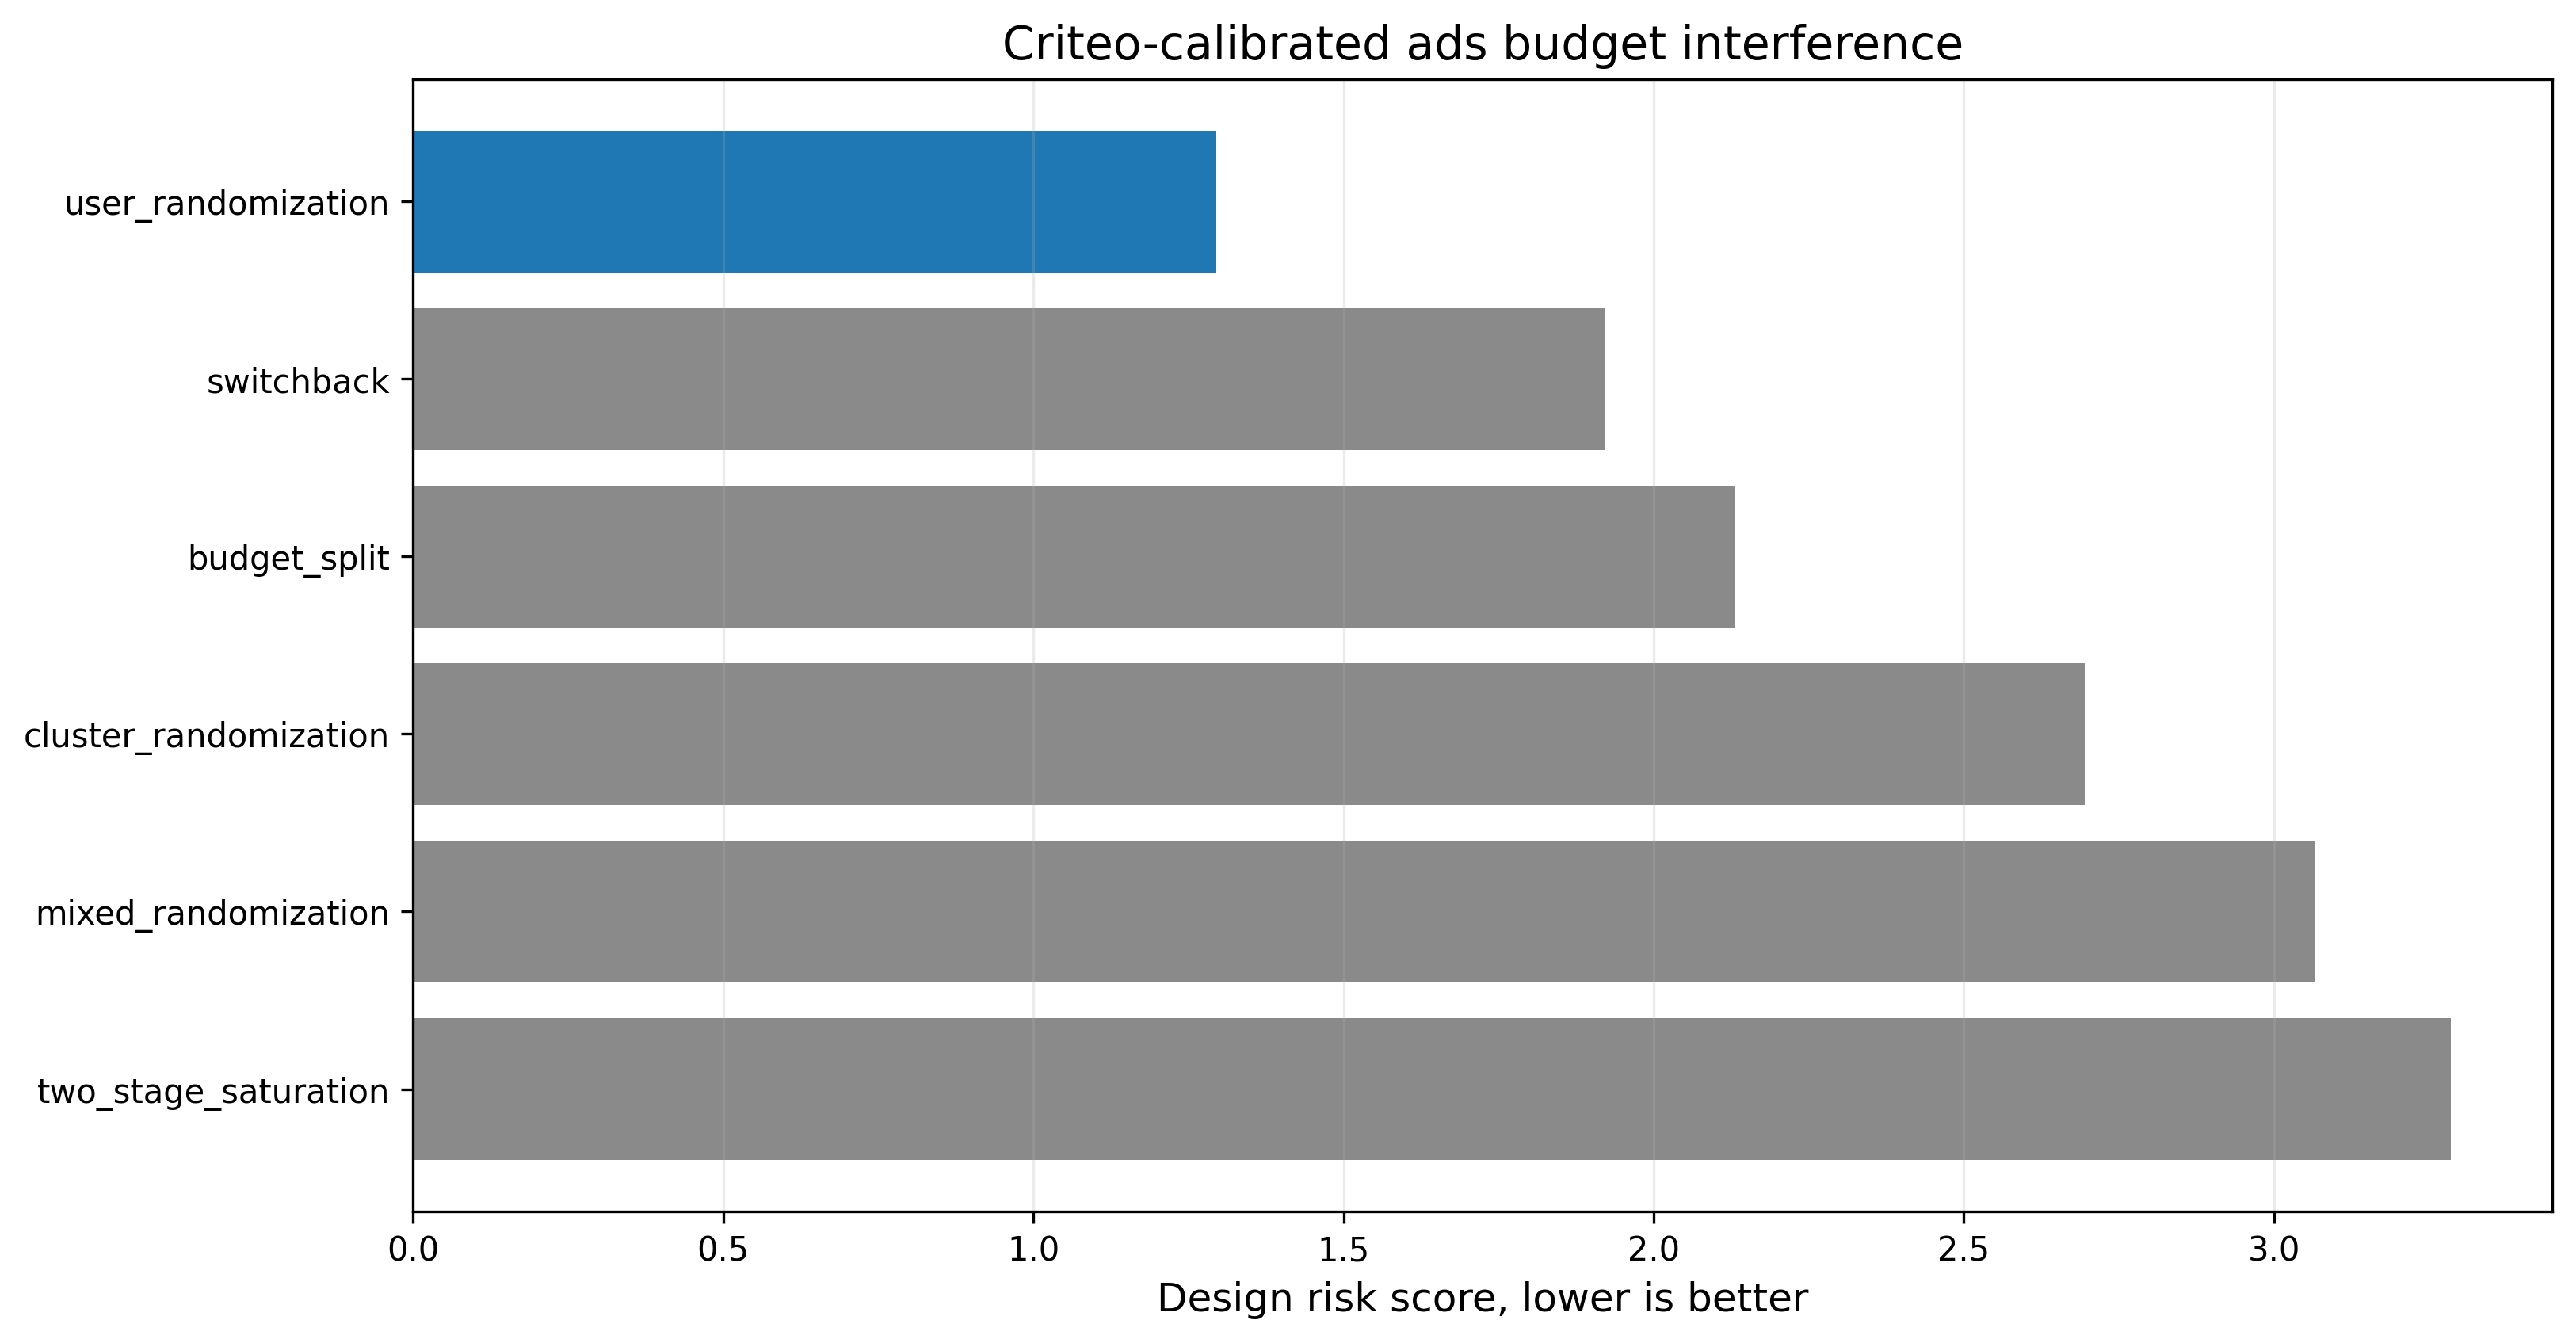

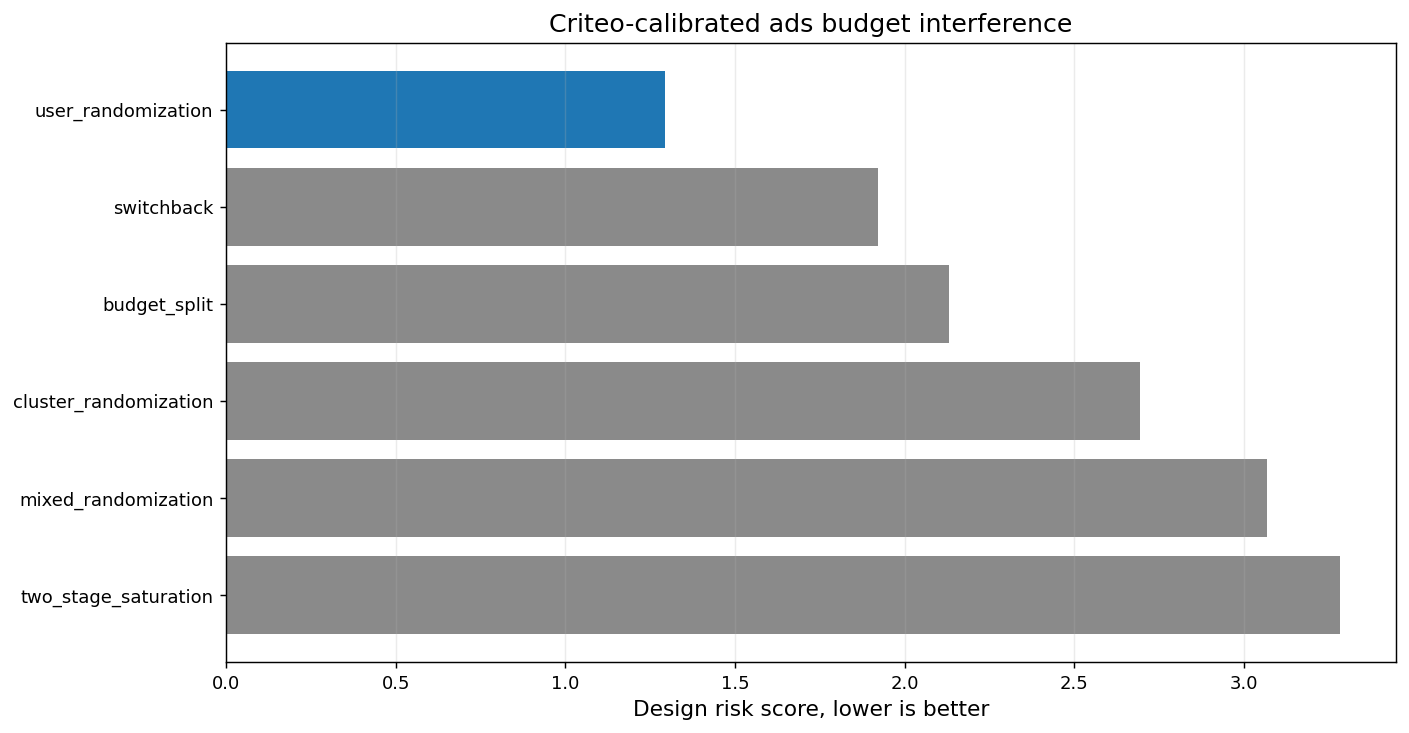

In [4]:
fig_path = paths.figure_dir / "02_criteo_ads_design_risk.png"
plot_design_risk(ranked, "Criteo-calibrated ads budget interference", fig_path)
display(Image(filename=str(fig_path)))

[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/02_criteo_ads_bias_variance_frontier.png


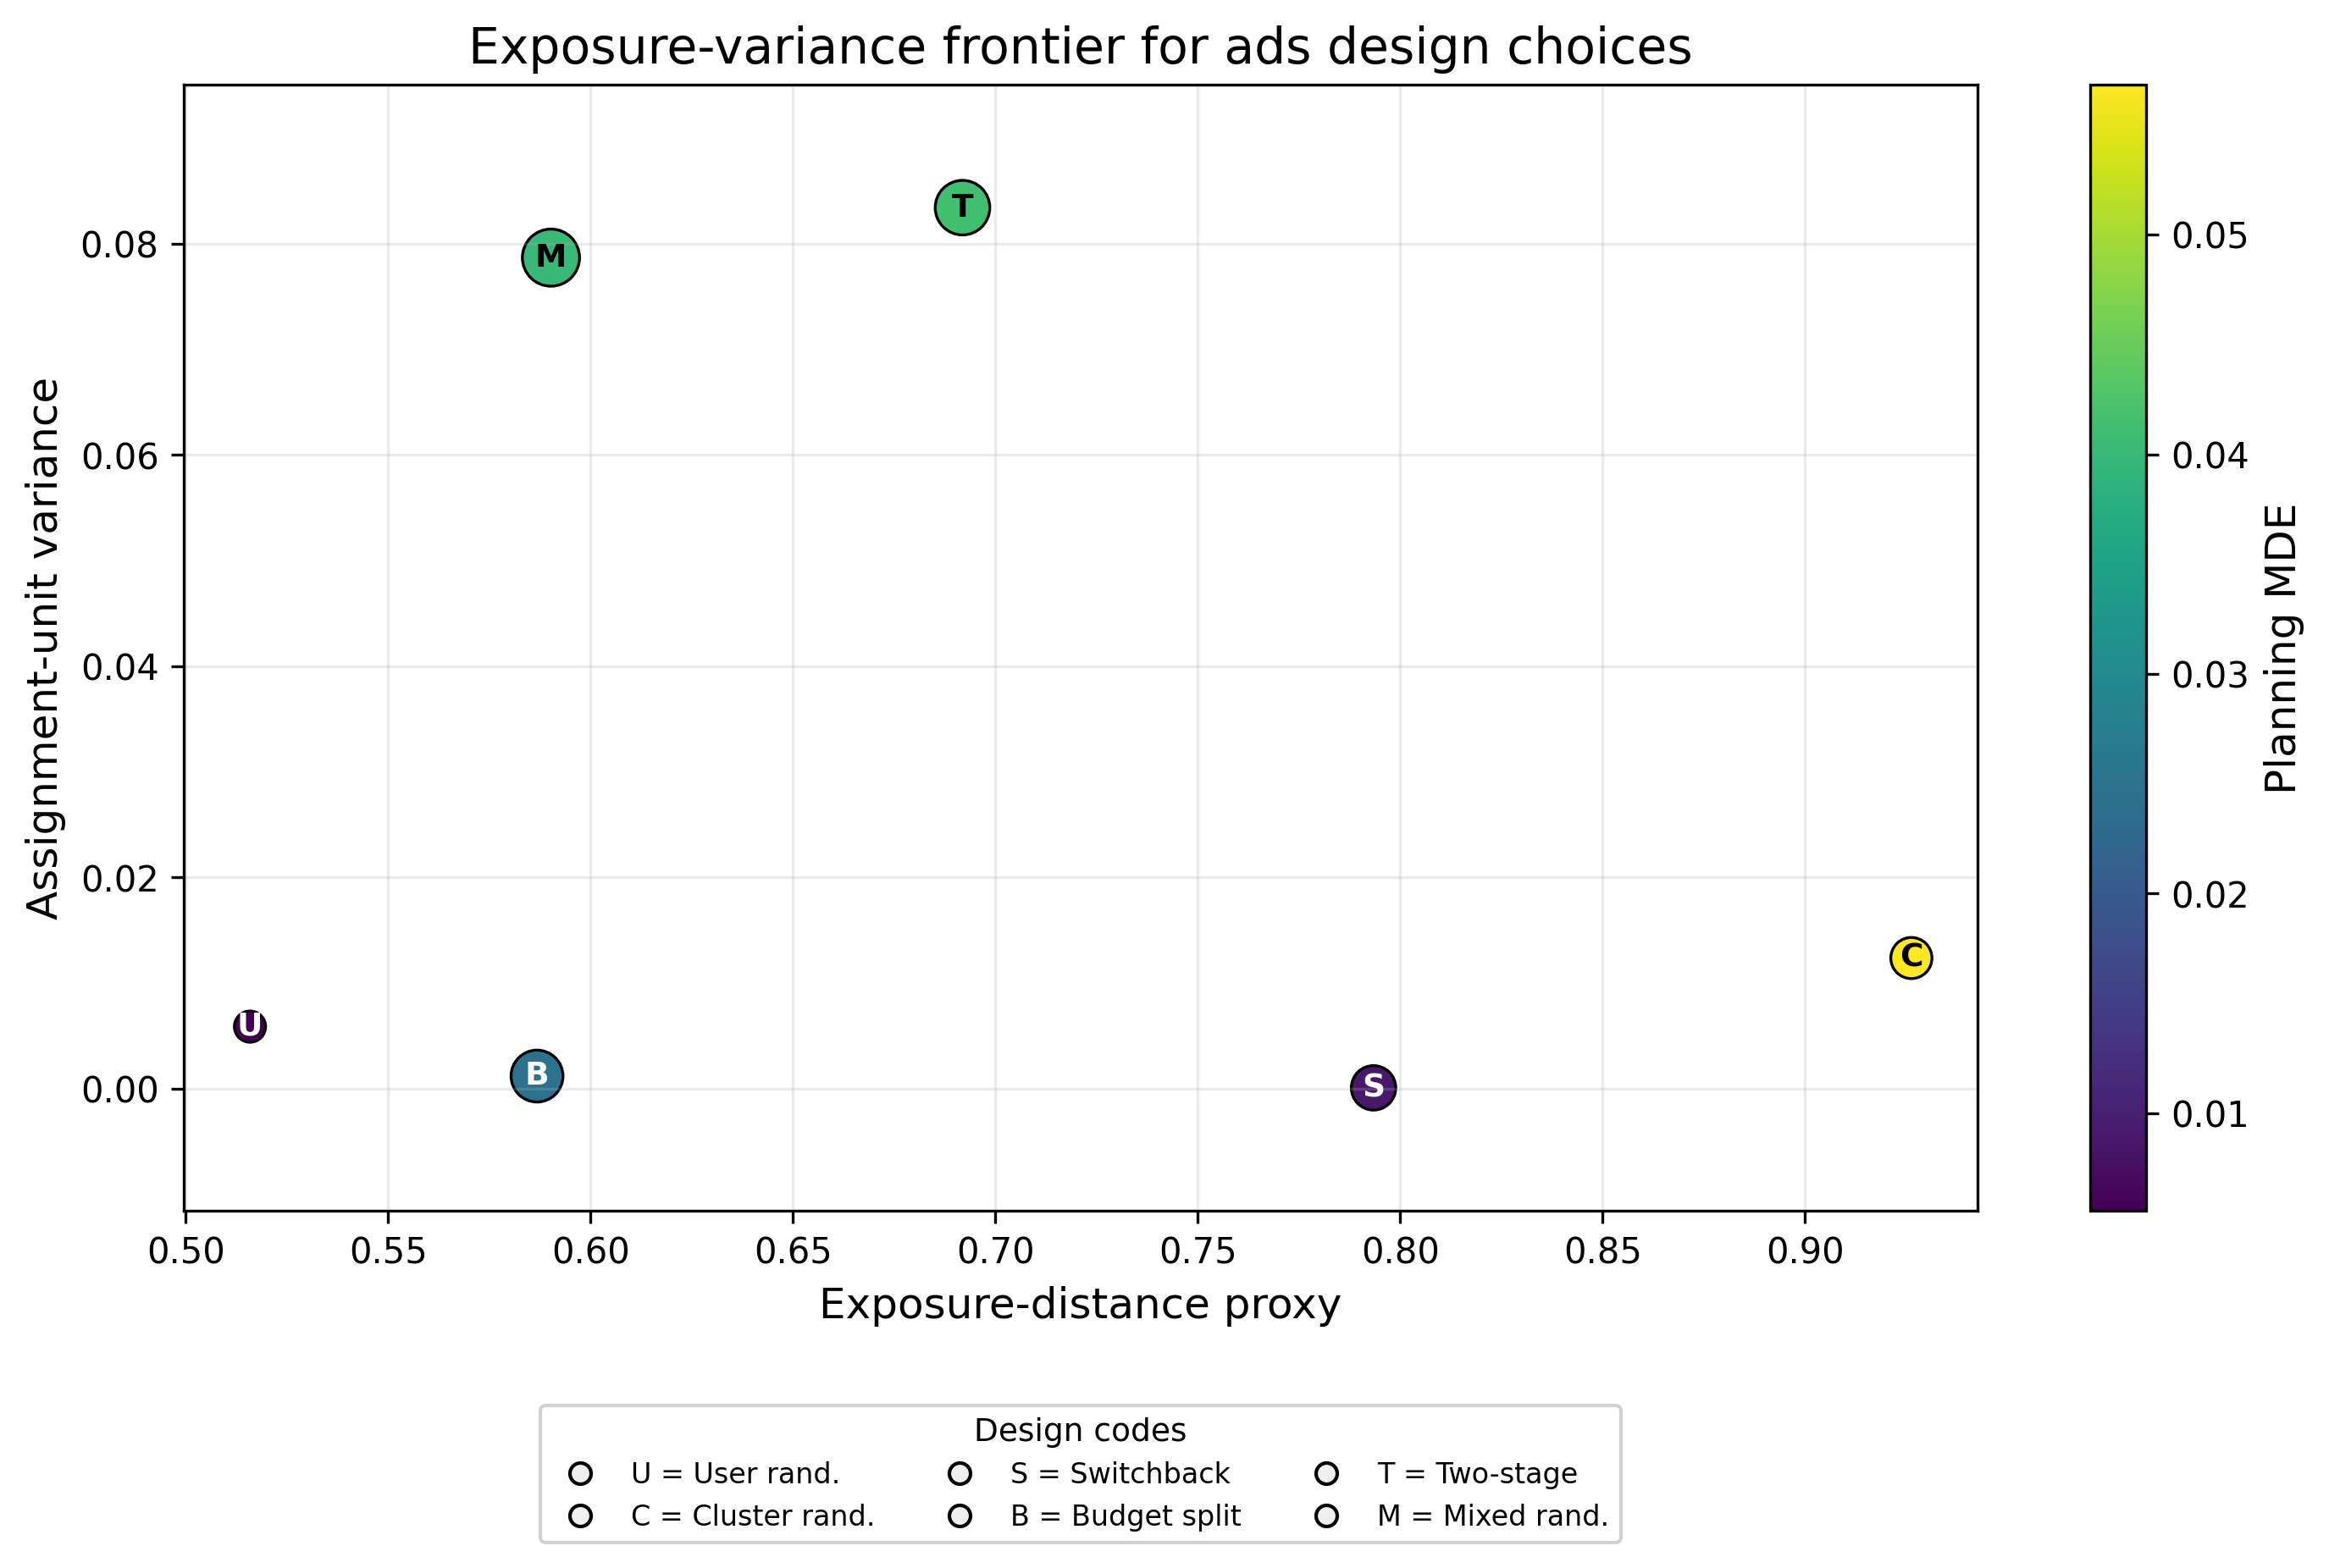

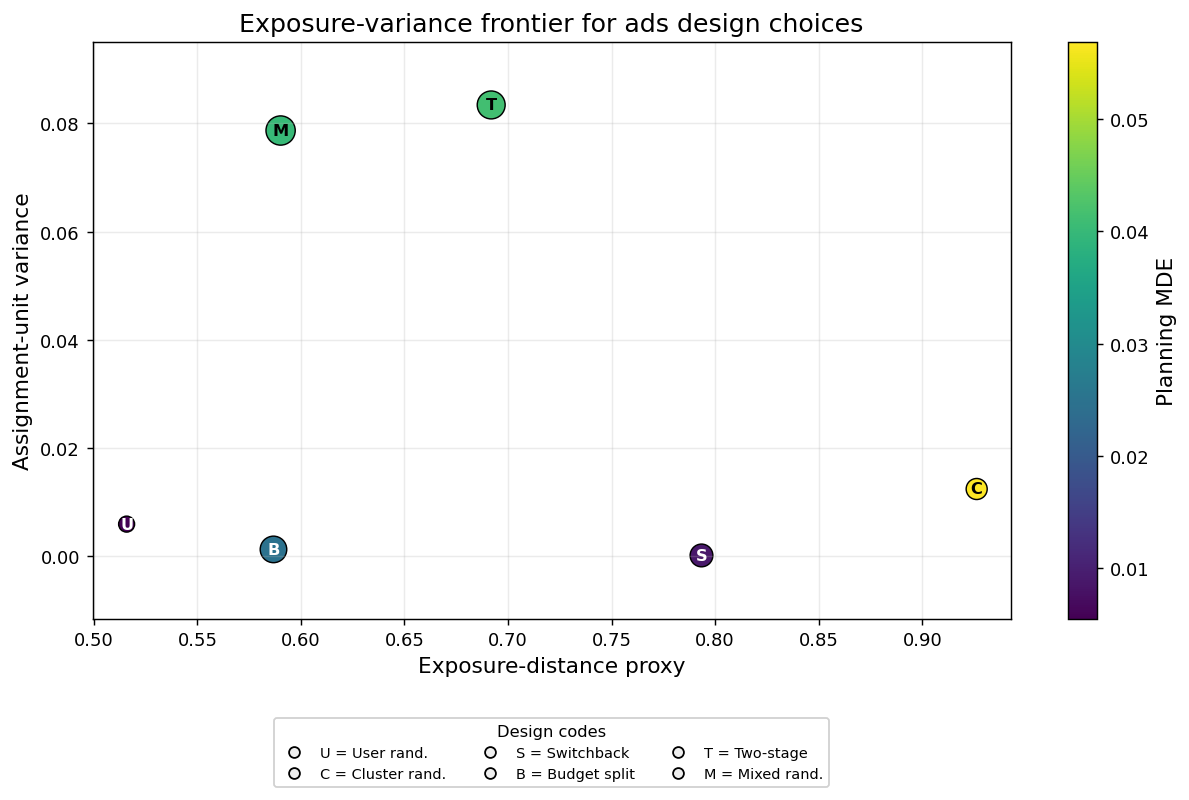

In [5]:
fig_path = paths.figure_dir / "02_criteo_ads_bias_variance_frontier.png"
plot_bias_variance_frontier(ranked, "Exposure-variance frontier for ads design choices", fig_path)
display(Image(filename=str(fig_path)))